In [2]:
# --- Task 1 (Setup & Exploratory Data Analysis - EDA) ---
import pandas as pd
import numpy as np
# Dummy Amazon Review Data 
data = {
    'Review_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product_Category': ['Electronics', 'Electronics', 'Home', 'Books', 'Electronics', 'Home', 'Books', 'Clothing', 'Clothing', 'Home'],
    'Rating': [5, 1, 4, 5, 2, 5, 3, 4, 1, 5],
    'Review_Text': [
        "This wireless headphone is absolutely amazing! Great sound quality.",
        "Worst product ever. It broke within two days of use. Disappointed.",
        "Very useful for daily chores, though delivery took some time.",
        "An absolute masterpiece! Loved the storyline and characters.",
        "Battery life is terrible. It doesn't even last for 2 hours.",
        "Perfect fit for my living room. High quality material.",
        "The book is okay, but the printing quality could be better.",
        "Very comfortable fabric and fits perfectly. Worth the price.",
        "Horrible experience. The size is completely wrong and looks cheap.",
        "Superb product! Highly recommend it to everyone."
    ]
}
# Change Data into DataFrame (table)
df = pd.DataFrame(data)

print("--- FIRST FIVE LINE OF DATASETS ---")
print(df.head())

print("\n--- DATA TYPES AND MISSING VALUES ---")
print(df.info())

--- FIRST FIVE LINE OF DATASETS ---
   Review_ID Product_Category  Rating  \
0        101      Electronics       5   
1        102      Electronics       1   
2        103             Home       4   
3        104            Books       5   
4        105      Electronics       2   

                                         Review_Text  
0  This wireless headphone is absolutely amazing!...  
1  Worst product ever. It broke within two days o...  
2  Very useful for daily chores, though delivery ...  
3  An absolute masterpiece! Loved the storyline a...  
4  Battery life is terrible. It doesn't even last...  

--- DATA TYPES AND MISSING VALUES ---
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Review_ID         10 non-null     int64
 1   Product_Category  10 non-null     str  
 2   Rating            10 non-null     int64
 3   Review_Text       10 non-nul

In [ ]:
#Task 1: Exploratory Data Analysis (EDA)
print("--- RATINGS KA SUMMARY STATISTICS ---")
# AVG RATTING AND MIN AUR MAX RATTING
print(df['Rating'].describe())

print("\n--- RATINGS AVERAGE BASED ON PRODUCT CATEGORY ---")
#FOR CHECK BEST REVIEW
print(df.groupby('Product_Category')['Rating'].mean())

# Feature Engineering: (Review Length)
df['Review_Length'] = df['Review_Text'].apply(len)

print("\n--- REVIEW LENGTH WITH SATH DATASET ---")
print(df[['Review_Text', 'Review_Length']].head())

--- RATINGS KA SUMMARY STATISTICS ---
count    10.000000
mean      3.500000
std       1.649916
min       1.000000
25%       2.250000
50%       4.000000
75%       5.000000
max       5.000000
Name: Rating, dtype: float64

--- RATINGS AVERAGE BASED ON PRODUCT CATEGORY ---
Product_Category
Books          4.000000
Clothing       2.500000
Electronics    2.666667
Home           4.666667
Name: Rating, dtype: float64

--- REVIEW LENGTH WITH SATH DATASET ---
                                         Review_Text  Review_Length
0  This wireless headphone is absolutely amazing!...             67
1  Worst product ever. It broke within two days o...             66
2  Very useful for daily chores, though delivery ...             61
3  An absolute masterpiece! Loved the storyline a...             60
4  Battery life is terrible. It doesn't even last...             59


In [6]:
# --- (TASK 2: SENTIMENT ANALYSIS) ---

from textblob import TextBlob

def analyze_sentiment(text):
    analysis = TextBlob(text)
    # polarity score
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Review_Text'].apply(analyze_sentiment)

print("--- SENTIMENT ANALYSIS RESULT ---")
print(df[['Review_Text', 'Sentiment']])

--- SENTIMENT ANALYSIS RESULT ---
                                         Review_Text Sentiment
0  This wireless headphone is absolutely amazing!...  Positive
1  Worst product ever. It broke within two days o...  Negative
2  Very useful for daily chores, though delivery ...  Positive
3  An absolute masterpiece! Loved the storyline a...  Positive
4  Battery life is terrible. It doesn't even last...  Negative
5  Perfect fit for my living room. High quality m...  Positive
6  The book is okay, but the printing quality cou...  Positive
7  Very comfortable fabric and fits perfectly. Wo...  Positive
8  Horrible experience. The size is completely wr...  Negative
9   Superb product! Highly recommend it to everyone.  Positive


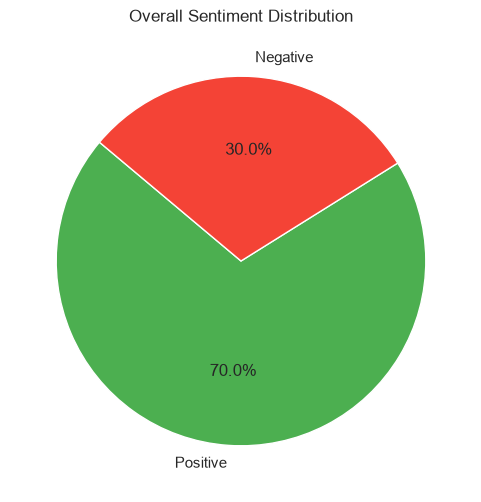

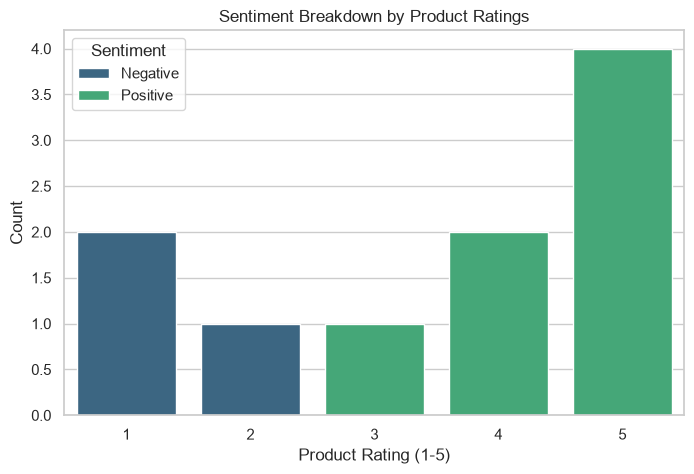

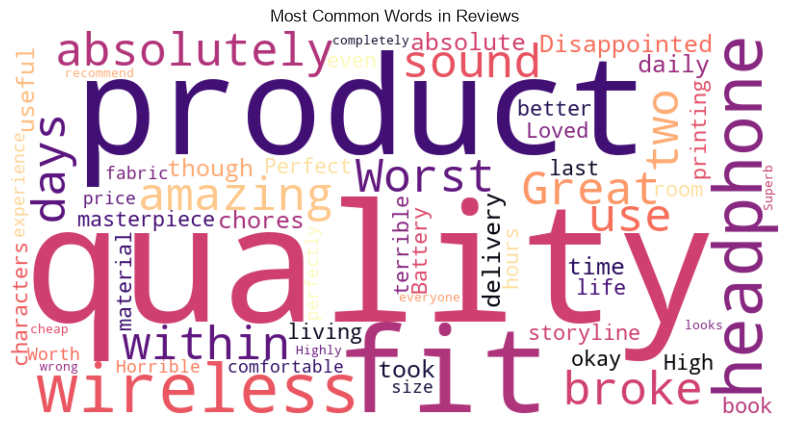

In [7]:
# --- (TASK 3: DATA VISUALIZATION) ---

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")

# 1. Sentiment Distribution Pie Chart
plt.figure(figsize=(6,6))
sentiment_counts = df['Sentiment'].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336', '#FFC107'], startangle=140)
plt.title('Overall Sentiment Distribution')
plt.show()

# 2. Rating vs Sentiment Bar Plot
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', hue='Sentiment', data=df, palette='viridis')
plt.title('Sentiment Breakdown by Product Ratings')
plt.xlabel('Product Rating (1-5)')
plt.ylabel('Count')
plt.show()

# 3. WordCloud (Frequent Words Visualization)
all_words = ' '.join([text for text in df['Review_Text']])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Reviews')
plt.show()